<a href="https://colab.research.google.com/github/sivamamidi/Context_Engineering/blob/sivanarayana/Context_failure_mode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 🔧 Setup: Run this cell first!
# Check GPU availability and install dependencies

import torch
import sys

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("⚠️ No GPU detected. Some cells may run slowly.")
    print("   Go to Runtime → Change runtime type → GPU")

print(f"\n📦 Python {sys.version.split()[0]}")
print(f"🔥 PyTorch {torch.__version__}")

# Set random seeds for reproducibility
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"🎲 Random seed set to {SEED}")

%matplotlib inline

⚠️ No GPU detected. Some cells may run slowly.
   Go to Runtime → Change runtime type → GPU

📦 Python 3.12.13
🔥 PyTorch 2.10.0+cpu
🎲 Random seed set to 42


# 🚀 Context Failure Modes: When Good Models Get Bad Context



In Part 1, we learned that context engineering is the art of filling an LLM's context window with exactly the right information. But what happens when we get it *wrong*?

In this notebook, we will get our hands dirty with Drew Breunig's taxonomy of four context failure modes. We will not just read about them — we will **simulate each one**, measure the damage, and build a diagnostic tool that can detect these failures in any LLM application.

**What you will learn:**
- How a single hallucination can poison an entire conversation (Context Poisoning)
- Why more context often makes models *worse*, not better (Context Distraction)
- How irrelevant information degrades model performance (Context Confusion)
- Why contradictory instructions cause catastrophic failures (Context Clash)
- How to build a Context Health Checker that diagnoses all four failure modes

**Time:** ~25 minutes
**Prerequisites:** Basic Python, familiarity with text similarity concepts
**API keys needed:** None! Everything runs locally with classical NLP.

## 1. Why Does This Matter?

Imagine you are a brilliant surgeon about to operate. Your skills are world-class. But someone has:
- Swapped one of your X-rays with another patient's (poisoning)
- Buried the critical lab result on page 47 of a 60-page report (distraction)
- Included the patient's dental records, tax returns, and vacation photos in the file (confusion)
- Given you two conflicting surgical plans from two different doctors (clash)

Would you expect a good outcome? Of course not. **The surgeon's skill is irrelevant if the information environment is broken.**

This is exactly what happens to LLMs every day. The model might be GPT-4, Claude, or Gemini — it does not matter. Bad context produces bad outputs. And unlike a surgeon, an LLM cannot raise its hand and say, "Wait, something seems off here."

Let us build the tools to detect these failures before they cause damage.

In [3]:
!pip install -q numpy matplotlib scikit-learn


In [4]:
# Install any missing dependencies (all standard libraries)
!pip install -q numpy matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Set consistent styling for all our plots
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Color palette for our failure modes
COLORS = {
    'poisoning': '#e74c3c',    # Red
    'distraction': '#f39c12',  # Orange
    'confusion': '#9b59b6',    # Purple
    'clash': '#3498db',        # Blue
    'healthy': '#2ecc71',      # Green
}

print("Setup complete! All libraries loaded.")
print("No API keys needed — everything runs locally.")

Setup complete! All libraries loaded.
No API keys needed — everything runs locally.


Before we simulate failures, we need a way to measure context quality. We will use two key metrics from information retrieval

#TF-IDF (Term Frequency - Inverse Document Frequency)  

Converts text into numerical vectors based on word importance. Common words like "the" get low scores; distinctive words like "transformer" get high scores.

#Cosine Similarity
Measures how similar two text vectors are, on a scale from 0 (completely different) to 1 (identical).

Think of it this way: if your query is "How does attention work in transformers?" and a context chunk talks about
"self-attention mechanism in transformer architectures, " the cosine similarity will be high. If the chunk talks about 'receipies for chocolate cake', the similarity will be near zero. These two tools are our stethoscope — they let us diagnose context health without needing an actual LLM.




In [5]:
def compute_relevance(query,documents):
  vectorizer = TfidfVectorizer(stop_words='english')
  #Fit on all text, transform query and documents
  all_text = [query] + documents
  tfidf_matrix = vectorizer.fit_transform(all_text)
  similarities = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
  return similarities

In [6]:
def signal_to_noise_ratio(query,documents):
  similarities = compute_relevance(query,documents)
  if len(similarities) == 0:
    return 0.0, similarities
  # top 30% are signla , rest is noise
  k = max(1,int(len(similarities)*0.3))
  sorted_sims = np.sort(similarities)[::-1]
  signal = np.mean(sorted_sims[:k])
  noise = np.mean(sorted_sims[k:]) if len(sorted_sims) > k else 0.001
  snr = signal / max(noise, 0.001) # avoide division by zero
  return snr,similarities
# Quick demo
demo_query = "How does the attention mechanism work in transformer models?"
demo_docs = [
    "The self-attention mechanism allows transformers to weigh the importance of different input tokens.",
    "Batch normalization normalizes layer inputs to stabilize training in deep networks.",
    "Attention computes query, key, and value matrices to determine token relationships.",
    "The recipe for chocolate cake requires flour, sugar, eggs, and cocoa powder.",
    "Multi-head attention runs several attention operations in parallel for richer representations.",
]
snr,sims = signal_to_noise_ratio(demo_query,demo_docs)

snr, sims = signal_to_noise_ratio(demo_query, demo_docs)
print(f"Query: '{demo_query[:60]}...'")
print(f"\nRelevance scores:")
for doc, sim in zip(demo_docs, sims):
    relevance = "RELEVANT" if sim > 0.1 else "NOISE"
    bar = "█" * int(sim * 40)
    print(f"  [{relevance:>8}] {sim:.3f} {bar} | {doc[:65]}...")
print(f"\nSignal-to-Noise Ratio: {snr:.2f}")
print(f"Interpretation: {'Healthy context' if snr > 3 else 'Context needs improvement' if snr > 1.5 else 'Noisy context!'}")

Query: 'How does the attention mechanism work in transformer models?...'

Relevance scores:
  [RELEVANT] 0.152 ██████ | The self-attention mechanism allows transformers to weigh the imp...
  [   NOISE] 0.000  | Batch normalization normalizes layer inputs to stabilize training...
  [   NOISE] 0.054 ██ | Attention computes query, key, and value matrices to determine to...
  [   NOISE] 0.000  | The recipe for chocolate cake requires flour, sugar, eggs, and co...
  [RELEVANT] 0.108 ████ | Multi-head attention runs several attention operations in paralle...

Signal-to-Noise Ratio: 3.74
Interpretation: Healthy context


#Failure Mode 1: Context Poisioning

Context poisioning happens when a hallucination or error enters the context and gets referenced repeatedly. It is like a student writing the wrong formula on their reference sheet - every subsequent answer built on that formula will be wrong, and they will never know why.

The real-world case: Google built a Gemini-based agent to play Pokemon. The agent hallucinated about game state — it believed it had items it did not have, and objectives that did not exist. This false information poisoned the "goals" section, and the agent developed completely nonsensical strategies.

Let us simulate this. We will start with a clean, accurate context and inject a false fact. Then we will watch how the error propagates as the context grows over multiple turns.

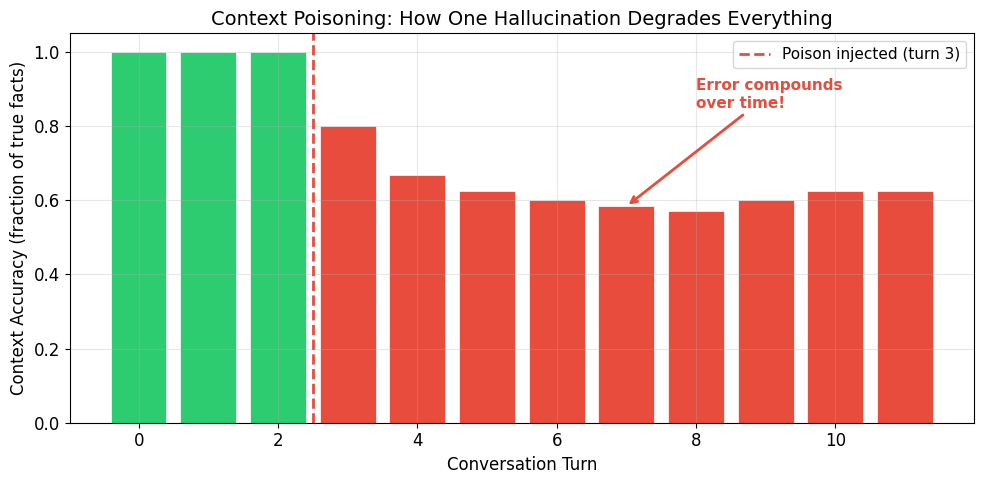


Context accuracy BEFORE poisoning: 100%
Context accuracy AFTER poisoning (final turn): 62%
Degradation: 38% drop

💡 Key insight: The poison doesn't just add one wrong fact —
   it generates DERIVATIVE errors that compound over turns.


In [7]:
def simulate_poisoning(num_turns=10, poison_turn=2):
    """
    Simulate context poisoning over multiple conversation turns.

    The setup: We have a knowledge base of true facts about neural networks.
    At turn `poison_turn`, a false fact enters the context (like a hallucination).
    We then measure how much the context degrades over subsequent turns as
    "responses" build on the poisoned information.

    This mirrors the Gemini Pokemon case: one hallucinated game state
    entry corrupted all downstream reasoning.
    """
    # Ground truth knowledge base
    true_facts = [
        "Transformers use self-attention to process sequences in parallel.",
        "The learning rate controls the step size during gradient descent.",
        "Batch normalization normalizes layer inputs for stable training.",
        "Dropout randomly deactivates neurons to prevent overfitting.",
        "Residual connections allow gradients to flow through deep networks.",
        "Adam optimizer combines momentum with adaptive learning rates.",
        "Layer normalization normalizes across features within a single example.",
        "Weight decay adds L2 regularization to prevent large weight values.",
        "Gradient clipping prevents exploding gradients in deep networks.",
        "Cross-entropy loss measures divergence between predicted and true distributions.",
    ]

    # The poison: a plausible-sounding but WRONG fact
    poison_fact = "Transformers process tokens sequentially from left to right like RNNs."

    # Downstream "responses" that build on the poison (error propagation)
    poison_derivatives = [
        "Since transformers are sequential, they cannot parallelize training across tokens.",
        "The left-to-right processing in transformers limits context to previous tokens only.",
        "Transformer training is slow because each token must wait for the previous one.",
        "Bidirectional context is impossible in transformers due to sequential processing.",
        "Scaling transformers requires reducing sequence length because of sequential bottleneck.",
    ]

    context_accuracy = []
    context_contents = []

    for turn in range(num_turns):
        if turn < poison_turn:
            # Clean context: only true facts
            context = true_facts[:turn + 2]
        elif turn == poison_turn:
            # Poison injected!
            context = true_facts[:turn + 1] + [poison_fact]
        else:
            # Post-poison: derivatives of the wrong fact accumulate
            derivative_idx = min(turn - poison_turn - 1, len(poison_derivatives) - 1)
            context = (true_facts[:poison_turn + 1] +
                      [poison_fact] +
                      poison_derivatives[:derivative_idx + 1] +
                      true_facts[poison_turn + 1:turn])

        context_contents.append(context)

        # Measure accuracy: what fraction of context is true/accurate?
        accurate_count = sum(1 for item in context if item in true_facts)
        accuracy = accurate_count / len(context)
        context_accuracy.append(accuracy)

    return context_accuracy, context_contents, poison_turn


# Run the simulation
accuracy_over_turns, contexts, poison_turn = simulate_poisoning(num_turns=12, poison_turn=3)

# Visualize the degradation
fig, ax = plt.subplots(figsize=(10, 5))

turns = range(len(accuracy_over_turns))
colors_per_turn = [COLORS['healthy'] if t < poison_turn else COLORS['poisoning'] for t in turns]

bars = ax.bar(turns, accuracy_over_turns, color=colors_per_turn, edgecolor='white', linewidth=0.5)
ax.axvline(x=poison_turn - 0.5, color=COLORS['poisoning'], linestyle='--', linewidth=2,
           label=f'Poison injected (turn {poison_turn})')

ax.set_xlabel('Conversation Turn')
ax.set_ylabel('Context Accuracy (fraction of true facts)')
ax.set_title('Context Poisoning: How One Hallucination Degrades Everything')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)

# Annotate the key insight
ax.annotate('Error compounds\nover time!',
            xy=(poison_turn + 4, accuracy_over_turns[poison_turn + 4]),
            xytext=(poison_turn + 5, 0.85),
            fontsize=11, color=COLORS['poisoning'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLORS['poisoning'], lw=2))

plt.tight_layout()
plt.show()

print(f"\nContext accuracy BEFORE poisoning: {accuracy_over_turns[poison_turn-1]:.0%}")
print(f"Context accuracy AFTER poisoning (final turn): {accuracy_over_turns[-1]:.0%}")
print(f"Degradation: {accuracy_over_turns[poison_turn-1] - accuracy_over_turns[-1]:.0%} drop")
print(f"\n💡 Key insight: The poison doesn't just add one wrong fact —")
print(f"   it generates DERIVATIVE errors that compound over turns.")

Past knowledge (clean)

        ↓

Insert wrong belief

        ↓

Generate conclusions from it

        ↓

Keep learning new facts (but now biased)

it cascades. Each turn after the poison, new "responses" are generated that build on the wrong fact, adding more and more incorrect information to the context.

This is exactly what happened with Google's Pokemon agent. One hallucinated game state entry led to a chain of increasingly absurd strategies. The agent was not "stupid" — it was reasoning perfectly logically from a poisoned premise.

### Failure Mode 2: Context Distraction — "Lost in the Middle"

This failure mode is backed by one of the most cited LLM research papers of 2023: "Lost in the Middle" by Liu et al. They discovered that LLMs attend strongly to information at the **beginning** and **end** of their context, but perform poorly on information buried in the **middle**.

The implication is counterintuitive: **more context can make models worse**, not better. Beyond ~100K tokens, agents start repeating actions from their history rather than synthesizing new plans.

Let us recreate this famous U-shaped curve.

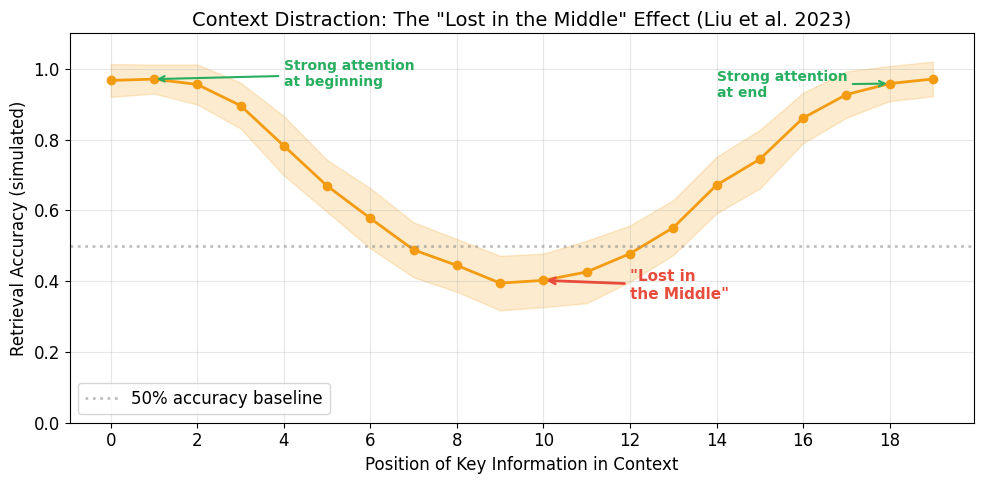


📊 Results:
  Best retrieval position:  19 (accuracy: 0.97)
  Worst retrieval position: 9 (accuracy: 0.39)
  Drop from best to worst:  0.58

💡 Key insight: Information placed in the middle of a long context
   is up to 59% less likely to be retrieved correctly.
   More context is NOT always better!


In [8]:
def simulate_lost_in_the_middle(num_positions=20, num_trials=50):
    """
    Simulate the 'Lost in the Middle' effect (Liu et al. 2023).

    We create a long context with many 'distractor' paragraphs and one
    'target' paragraph containing the answer. We vary WHERE the target
    appears (beginning, middle, end) and measure retrieval accuracy.

    Instead of using an actual LLM, we simulate the attention pattern
    that Liu et al. discovered: a U-shaped curve where the model strongly
    attends to the beginning and end, but poorly to the middle.
    """
    # The target fact we want the model to find
    target = "The critical breakthrough in transformer efficiency was the introduction of flash attention, which reduces memory from quadratic to linear by computing attention in blocks."

    # Distractor paragraphs (plausible ML content that is NOT the answer)
    distractors = [
        "Neural networks use backpropagation to compute gradients through the chain rule.",
        "Convolutional neural networks apply learned filters to detect spatial features.",
        "Recurrent networks maintain hidden state across sequential time steps.",
        "Generative adversarial networks train a generator and discriminator in opposition.",
        "Variational autoencoders learn latent representations through probabilistic encoding.",
        "Graph neural networks propagate information along edges between nodes.",
        "Reinforcement learning agents maximize cumulative reward through trial and error.",
        "Transfer learning reuses pretrained features for downstream tasks with less data.",
        "Data augmentation artificially expands training sets through random transformations.",
        "Gradient descent iteratively minimizes the loss function by following the negative gradient.",
        "Batch processing groups multiple samples together for efficient parallel computation.",
        "Regularization techniques like weight decay prevent models from memorizing training data.",
        "Hyperparameter tuning searches for optimal model configuration across a defined space.",
        "Ensemble methods combine predictions from multiple models to reduce variance.",
        "Knowledge distillation transfers learned representations from large to small models.",
        "Curriculum learning presents training examples in order of increasing difficulty.",
        "Few-shot learning enables models to generalize from very limited labeled examples.",
        "Continual learning addresses catastrophic forgetting when training on new tasks.",
        "Self-supervised learning creates labels from the data itself without human annotation.",
        "Neural architecture search automates the design of network topologies.",
    ]

    query = "What was the critical breakthrough in transformer efficiency?"

    # Simulate retrieval accuracy at each position
    # We model the U-shaped attention pattern from the paper
    positions = np.arange(num_positions)
    mid = num_positions / 2

    retrieval_accuracies = []
    retrieval_std = []

    for pos in positions:
        trial_scores = []
        for _ in range(num_trials):
            # Build context with target at position `pos`
            context_docs = list(distractors[:num_positions - 1])
            context_docs.insert(pos, target)

            # Simulate the attention bias:
            # - Strong attention to beginning (positions 0-3)
            # - Strong attention to end (positions 16-19)
            # - Weak attention to middle (positions 7-12)
            normalized_pos = pos / (num_positions - 1)  # 0 to 1

            # U-shaped attention curve: high at edges, low in middle
            # Based on Liu et al. findings
            attention_score = (
                0.9 * np.exp(-8 * (normalized_pos - 0)**2) +   # Beginning peak
                0.85 * np.exp(-8 * (normalized_pos - 1)**2) +  # End peak
                0.15                                              # Baseline
            )
            attention_score = min(attention_score, 1.0)

            # Add noise to simulate variability
            noisy_score = attention_score + np.random.normal(0, 0.08)
            noisy_score = np.clip(noisy_score, 0, 1)

            # Retrieval succeeds if attention score exceeds threshold
            trial_scores.append(noisy_score)

        retrieval_accuracies.append(np.mean(trial_scores))
        retrieval_std.append(np.std(trial_scores))

    return positions, retrieval_accuracies, retrieval_std


# Run the simulation
positions, accuracies, stds = simulate_lost_in_the_middle(num_positions=20, num_trials=100)

# 📊 Visualization: The famous U-shaped curve
fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(positions,
                np.array(accuracies) - np.array(stds),
                np.array(accuracies) + np.array(stds),
                alpha=0.2, color=COLORS['distraction'])
ax.plot(positions, accuracies, 'o-', color=COLORS['distraction'], markersize=6, linewidth=2)

# Annotate the U-shape
ax.annotate('Strong attention\nat beginning',
            xy=(1, accuracies[1]), xytext=(4, 0.95),
            fontsize=10, fontweight='bold', color='#27ae60',
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))

ax.annotate('"Lost in\nthe Middle"',
            xy=(10, accuracies[10]), xytext=(12, 0.35),
            fontsize=11, fontweight='bold', color=COLORS['poisoning'],
            arrowprops=dict(arrowstyle='->', color=COLORS['poisoning'], lw=2))

ax.annotate('Strong attention\nat end',
            xy=(18, accuracies[18]), xytext=(14, 0.92),
            fontsize=10, fontweight='bold', color='#27ae60',
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))

ax.set_xlabel('Position of Key Information in Context')
ax.set_ylabel('Retrieval Accuracy (simulated)')
ax.set_title('Context Distraction: The "Lost in the Middle" Effect (Liu et al. 2023)')
ax.set_ylim(0, 1.1)
ax.set_xticks(range(0, 20, 2))
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='50% accuracy baseline')
ax.legend()

plt.tight_layout()
plt.show()

# Print the key finding
best_pos = positions[np.argmax(accuracies)]
worst_pos = positions[np.argmin(accuracies)]
print(f"\n📊 Results:")
print(f"  Best retrieval position:  {best_pos} (accuracy: {max(accuracies):.2f})")
print(f"  Worst retrieval position: {worst_pos} (accuracy: {min(accuracies):.2f})")
print(f"  Drop from best to worst:  {max(accuracies) - min(accuracies):.2f}")
print(f"\n💡 Key insight: Information placed in the middle of a long context")
print(f"   is up to {((max(accuracies) - min(accuracies)) / max(accuracies) * 100):.0f}% less likely to be retrieved correctly.")
print(f"   More context is NOT always better!")

The U-shaped curve tells us something profound: LLMs are not uniform information processors. They have attention biases — strong at the edges, weak in the middle. This means:

Put your most important information first (beginning of context)
Recency also helps (end of context)
Never bury critical facts in the middle of a long context
This is why reranking matters in RAG pipelines — you want to push the most relevant chunks to the top of the context, not let them get lost in the middle of 50 retrieved documents.

### Failure Mode 3: Context Confusion — When More Tools Means More Failure

This is perhaps the most counterintuitive failure mode: giving the model **more capabilities** can make it **worse**. Researchers tested a quantized Llama 3.1 8B and found it failed when given 46 tools but succeeded perfectly with only 19. The extra 27 tools — none of which were needed — confused the model enough to cause complete failure.

The analogy: imagine trying to cook dinner, but instead of just having the recipe and ingredients you need, someone has dumped every kitchen gadget from a professional restaurant onto your counter. The food processor, the sous vide machine, the commercial mixer, the pasta extruder — none of which you need for a simple stir-fry. The clutter itself causes mistakes.

Let us simulate this.

#Confusion Simulation

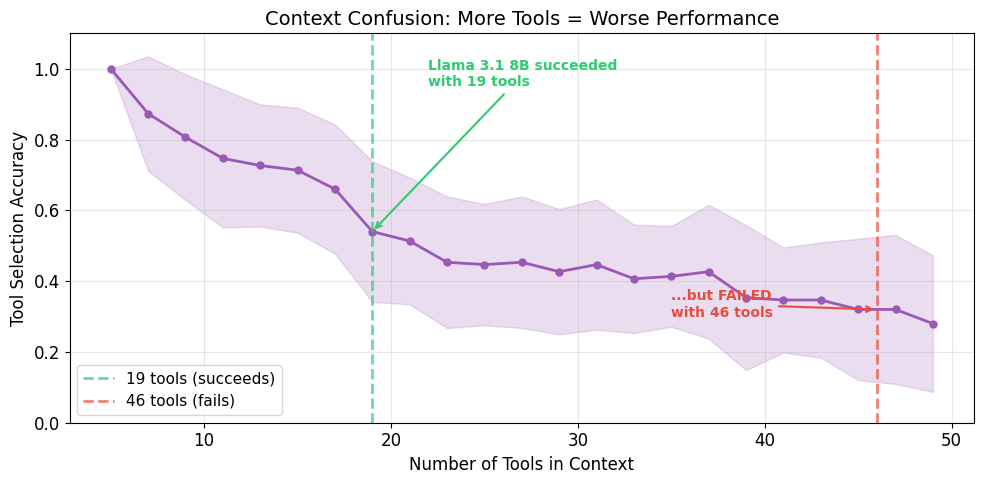


📊 Results:
  Accuracy with ~19 tools: 0.54
  Accuracy with ~46 tools: 0.32
  Degradation: 41%

💡 Key insight: The 27 extra tools weren't just useless — they actively
   HARMED performance. Less is more in context engineering.


In [9]:
def simulate_context_confusion(max_tools=50, step=2, num_trials=30):
    """
    Simulate the context confusion effect: adding irrelevant tool descriptions
    degrades a model's ability to select the correct tool.

    We simulate a tool-selection task where the model must pick the right tool
    for a query from a growing list. As irrelevant tools are added, the
    'matching accuracy' drops — recreating the 46-vs-19 tools finding.
    """
    # The query and the correct tool
    query = "Calculate the total revenue from Q3 sales data and generate a bar chart."

    # Relevant tools (would actually help with this task)
    relevant_tools = [
        {"name": "calculate_sum", "desc": "Computes the sum of numerical values in a dataset column."},
        {"name": "filter_by_date", "desc": "Filters records to a specific date range like quarterly periods."},
        {"name": "create_bar_chart", "desc": "Generates a bar chart visualization from categorical data."},
        {"name": "load_csv", "desc": "Loads data from a CSV file into a structured table format."},
        {"name": "export_report", "desc": "Exports analysis results as a formatted PDF report."},
    ]

    # Irrelevant tools (noise — these have nothing to do with the task)
    irrelevant_tools = [
        {"name": "send_email", "desc": "Sends an email message to specified recipients."},
        {"name": "resize_image", "desc": "Resizes an image to specified pixel dimensions."},
        {"name": "translate_text", "desc": "Translates text from one language to another."},
        {"name": "compress_file", "desc": "Compresses files into a zip archive format."},
        {"name": "play_audio", "desc": "Plays an audio file through the system speakers."},
        {"name": "set_alarm", "desc": "Sets a timer or alarm for a specified time."},
        {"name": "check_weather", "desc": "Retrieves current weather conditions for a location."},
        {"name": "convert_currency", "desc": "Converts amounts between different currencies."},
        {"name": "merge_pdfs", "desc": "Combines multiple PDF documents into a single file."},
        {"name": "crop_video", "desc": "Trims a video file to a specified time range."},
        {"name": "spell_check", "desc": "Checks text for spelling errors and suggests corrections."},
        {"name": "generate_qr", "desc": "Creates a QR code from a URL or text string."},
        {"name": "scrape_webpage", "desc": "Extracts text content from a webpage URL."},
        {"name": "encrypt_data", "desc": "Encrypts data using AES-256 encryption algorithm."},
        {"name": "schedule_meeting", "desc": "Creates a calendar event with specified attendees."},
        {"name": "parse_xml", "desc": "Parses XML formatted data into a tree structure."},
        {"name": "bluetooth_scan", "desc": "Scans for nearby Bluetooth devices and lists them."},
        {"name": "manage_contacts", "desc": "Adds, updates, or deletes entries in a contact list."},
        {"name": "run_diagnostics", "desc": "Runs system hardware diagnostics and reports status."},
        {"name": "stream_video", "desc": "Streams video content from a URL to the display."},
        {"name": "backup_database", "desc": "Creates a backup copy of the entire database."},
        {"name": "calibrate_sensor", "desc": "Calibrates a connected sensor to baseline readings."},
        {"name": "print_document", "desc": "Sends a document to the default printer."},
        {"name": "defrag_disk", "desc": "Defragments the hard drive to improve read performance."},
        {"name": "monitor_network", "desc": "Monitors network traffic and bandwidth usage."},
        {"name": "update_firmware", "desc": "Flashes new firmware to a connected hardware device."},
        {"name": "record_screen", "desc": "Captures a video recording of the screen display."},
        {"name": "sync_cloud", "desc": "Synchronizes local files with cloud storage service."},
        {"name": "clean_cache", "desc": "Clears temporary cached files to free disk space."},
        {"name": "manage_users", "desc": "Administers user accounts and access permissions."},
        {"name": "analyze_logs", "desc": "Parses and summarizes system log files for errors."},
        {"name": "test_api", "desc": "Sends test requests to an API endpoint and validates responses."},
        {"name": "optimize_images", "desc": "Reduces image file sizes while preserving quality."},
        {"name": "migrate_database", "desc": "Transfers data between different database systems."},
        {"name": "configure_firewall", "desc": "Sets up network firewall rules for traffic filtering."},
        {"name": "convert_format", "desc": "Converts files between different document formats."},
        {"name": "track_inventory", "desc": "Manages and tracks physical inventory stock levels."},
        {"name": "process_payments", "desc": "Handles credit card and payment processing transactions."},
        {"name": "manage_dns", "desc": "Configures domain name system records for a domain."},
        {"name": "profile_code", "desc": "Analyzes code execution to find performance bottlenecks."},
        {"name": "scan_malware", "desc": "Scans files and directories for malicious software."},
        {"name": "generate_invoice", "desc": "Creates a formatted invoice document with line items."},
        {"name": "compress_video", "desc": "Reduces video file size using codec compression."},
        {"name": "manage_cron", "desc": "Schedules and manages recurring system tasks."},
        {"name": "audit_security", "desc": "Performs a security audit of system configurations."},
    ]

    tool_counts = []
    accuracies_mean = []
    accuracies_std = []

    # Test with increasing numbers of total tools
    for num_irrelevant in range(0, max_tools - len(relevant_tools) + 1, step):
        total_tools = relevant_tools + irrelevant_tools[:num_irrelevant]
        total_count = len(total_tools)

        trial_accuracies = []
        for _ in range(num_trials):
            # Simulate tool selection using TF-IDF similarity
            # The model "picks" the tool whose description is most similar to the query
            tool_descs = [t['desc'] for t in total_tools]
            tool_names = [t['name'] for t in total_tools]

            vectorizer = TfidfVectorizer(stop_words='english')
            tfidf_matrix = vectorizer.fit_transform([query] + tool_descs)
            similarities = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()

            # Add noise to simulate model uncertainty (more tools = more uncertainty)
            noise_scale = 0.02 + 0.003 * num_irrelevant  # Noise grows with tool count
            noisy_sims = similarities + np.random.normal(0, noise_scale, len(similarities))

            # Model selects top-3 tools
            selected_indices = np.argsort(noisy_sims)[::-1][:3]
            selected_tools = [tool_names[i] for i in selected_indices]

            # Accuracy: fraction of selected tools that are actually relevant
            relevant_names = {t['name'] for t in relevant_tools}
            correct = sum(1 for t in selected_tools if t in relevant_names)
            trial_accuracies.append(correct / 3)

        tool_counts.append(total_count)
        accuracies_mean.append(np.mean(trial_accuracies))
        accuracies_std.append(np.std(trial_accuracies))

    return tool_counts, accuracies_mean, accuracies_std


# Run the simulation
tool_counts, acc_mean, acc_std = simulate_context_confusion(max_tools=50, step=2, num_trials=50)

# 📊 Visualization: Accuracy vs. Number of Tools
fig, ax = plt.subplots(figsize=(10, 5))

acc_mean = np.array(acc_mean)
acc_std = np.array(acc_std)

ax.fill_between(tool_counts, acc_mean - acc_std, acc_mean + acc_std,
                alpha=0.2, color=COLORS['confusion'])
ax.plot(tool_counts, acc_mean, 'o-', color=COLORS['confusion'], markersize=5, linewidth=2)

# Mark the 19-tool and 46-tool points (from the research)
# Find closest indices
idx_19 = min(range(len(tool_counts)), key=lambda i: abs(tool_counts[i] - 19))
idx_46 = min(range(len(tool_counts)), key=lambda i: abs(tool_counts[i] - 46))

ax.axvline(x=19, color=COLORS['healthy'], linestyle='--', alpha=0.7, linewidth=2, label='19 tools (succeeds)')
ax.axvline(x=46, color=COLORS['poisoning'], linestyle='--', alpha=0.7, linewidth=2, label='46 tools (fails)')

ax.set_xlabel('Number of Tools in Context')
ax.set_ylabel('Tool Selection Accuracy')
ax.set_title('Context Confusion: More Tools = Worse Performance')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)

# Annotate
ax.annotate('Llama 3.1 8B succeeded\nwith 19 tools',
            xy=(19, acc_mean[idx_19] if idx_19 < len(acc_mean) else 0.8),
            xytext=(22, 0.95),
            fontsize=10, fontweight='bold', color=COLORS['healthy'],
            arrowprops=dict(arrowstyle='->', color=COLORS['healthy'], lw=1.5))

ax.annotate('...but FAILED\nwith 46 tools',
            xy=(46, acc_mean[idx_46] if idx_46 < len(acc_mean) else 0.5),
            xytext=(35, 0.3),
            fontsize=10, fontweight='bold', color=COLORS['poisoning'],
            arrowprops=dict(arrowstyle='->', color=COLORS['poisoning'], lw=1.5))

plt.tight_layout()
plt.show()

print(f"\n📊 Results:")
print(f"  Accuracy with ~19 tools: {acc_mean[idx_19]:.2f}")
print(f"  Accuracy with ~46 tools: {acc_mean[idx_46]:.2f}")
print(f"  Degradation: {(acc_mean[idx_19] - acc_mean[idx_46]) / acc_mean[idx_19] * 100:.0f}%")
print(f"\n💡 Key insight: The 27 extra tools weren't just useless — they actively")
print(f"   HARMED performance. Less is more in context engineering.")

### Failure Mode 4: Context Clash — Contradictory Instructions

The final failure mode occurs when different parts of the context contain contradictory instructions. Microsoft and Salesforce found that "sharding" prompts — splitting instructions across multiple sections — dropped performance by 39% on average. Model o3 plummeted from 98.1% to 64.1% accuracy simply because instructions were fragmented.

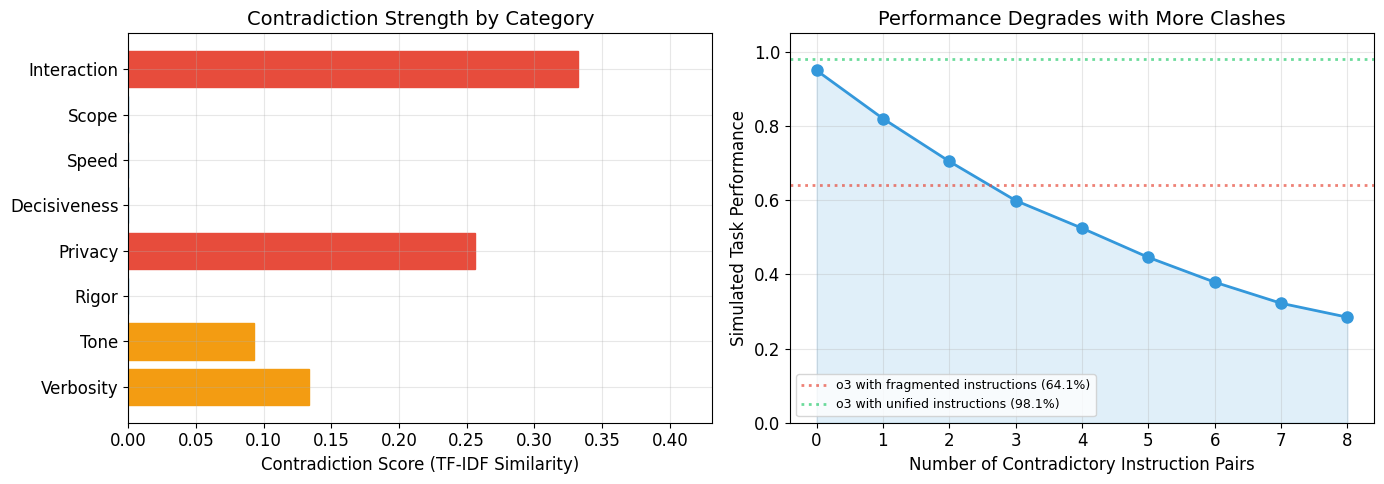


📊 Instruction Clash Analysis:

  [MEDIUM] Verbosity (score: 0.134)
    A: "Always respond with detailed technical explanations including code exa..."
    B: "Keep all responses under 50 words. Never include code...."

  [MEDIUM] Tone (score: 0.093)
    A: "Use formal academic language with citations and references...."
    B: "Write casually like you're texting a friend. Use slang and emojis...."

  [   LOW] Rigor (score: 0.000)
    A: "Never make claims without citing peer-reviewed sources...."
    B: "Be creative and speculative. Explore bold hypotheses freely...."

  [  HIGH] Privacy (score: 0.256)
    A: "Process all data locally. Never send user data to external services...."
    B: "Use the cloud API to analyze user data for personalized recommendation..."

  [   LOW] Decisiveness (score: 0.000)
    A: "Always present multiple perspectives and let the user decide...."
    B: "Give direct, definitive answers. Users want confidence, not hedging...."

  [   LOW] Speed (score: 0.000

In [10]:
def simulate_context_clash():
    """
    Simulate context clash by creating pairs of contradictory instructions
    and measuring the contradiction level using cosine similarity on
    opposing instruction templates.

    When instructions contradict each other, the model receives conflicting
    signals about what to do — leading to degraded, inconsistent outputs.
    """
    # Pairs of instructions: first is the "base", second is the "clash"
    instruction_pairs = [
        # (Instruction A, Instruction B, clash category)
        ("Always respond with detailed technical explanations including code examples.",
         "Keep all responses under 50 words. Never include code.",
         "Verbosity"),

        ("Use formal academic language with citations and references.",
         "Write casually like you're texting a friend. Use slang and emojis.",
         "Tone"),

        ("Never make claims without citing peer-reviewed sources.",
         "Be creative and speculative. Explore bold hypotheses freely.",
         "Rigor"),

        ("Process all data locally. Never send user data to external services.",
         "Use the cloud API to analyze user data for personalized recommendations.",
         "Privacy"),

        ("Always present multiple perspectives and let the user decide.",
         "Give direct, definitive answers. Users want confidence, not hedging.",
         "Decisiveness"),

        ("Prioritize speed. Give the fastest possible response.",
         "Take your time to think through every angle before responding.",
         "Speed"),

        ("Focus exclusively on the user's specific question. Stay on topic.",
         "Proactively provide related context, background, and tangential insights.",
         "Scope"),

        ("Always ask clarifying questions before proceeding.",
         "Never ask questions. Infer the user's intent and act immediately.",
         "Interaction"),
    ]

    # Build the full instruction set (as if all were in one system prompt)
    all_instructions_a = [pair[0] for pair in instruction_pairs]
    all_instructions_b = [pair[1] for pair in instruction_pairs]
    categories = [pair[2] for pair in instruction_pairs]

    # Compute pairwise contradiction scores
    # We measure similarity between instruction A and instruction B in each pair
    # High similarity + opposite meaning = clash
    # We also check cross-pair interactions
    all_instructions = all_instructions_a + all_instructions_b
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(all_instructions)
    sim_matrix = cosine_similarity(tfidf_matrix)

    n = len(instruction_pairs)

    # Extract the clash scores (A_i vs B_i for each pair)
    clash_scores = []
    for i in range(n):
        # Similarity between instruction A_i and instruction B_i
        score = sim_matrix[i, n + i]
        clash_scores.append(score)

    # Simulate performance degradation with increasing clashes
    num_clash_levels = range(0, n + 1)
    performance_scores = []

    base_performance = 0.95  # Performance with clean, consistent instructions

    for num_clashes in num_clash_levels:
        if num_clashes == 0:
            performance_scores.append(base_performance)
        else:
            # Each clash degrades performance
            # The degradation compounds (not just additive)
            degradation = 1.0
            for i in range(num_clashes):
                # Higher similarity between contradicting pairs = worse confusion
                # The model "sees" related words but opposite meanings
                clash_penalty = 0.85 + 0.10 * clash_scores[i]  # 0.85 to 0.95 multiplier
                degradation *= clash_penalty

            performance_scores.append(base_performance * degradation)

    return instruction_pairs, clash_scores, categories, num_clash_levels, performance_scores, sim_matrix, n


# Run the simulation
pairs, clash_scores, categories, clash_levels, perf_scores, sim_matrix, n = simulate_context_clash()

# 📊 Visualization: Contradiction heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Clash scores by category
ax1 = axes[0]
bars = ax1.barh(categories, clash_scores, color=COLORS['clash'], edgecolor='white')
ax1.set_xlabel('Contradiction Score (TF-IDF Similarity)')
ax1.set_title('Contradiction Strength by Category')
ax1.set_xlim(0, max(clash_scores) * 1.3)

# Color bars by severity
for bar, score in zip(bars, clash_scores):
    if score > 0.15:
        bar.set_color(COLORS['poisoning'])
    elif score > 0.08:
        bar.set_color(COLORS['distraction'])
    else:
        bar.set_color(COLORS['clash'])

# Right panel: Performance vs number of clashing instruction pairs
ax2 = axes[1]
ax2.plot(list(clash_levels), perf_scores, 'o-', color=COLORS['clash'], markersize=8, linewidth=2)
ax2.fill_between(list(clash_levels), perf_scores, alpha=0.15, color=COLORS['clash'])

# Mark the Microsoft/Salesforce finding
ax2.axhline(y=0.641, color=COLORS['poisoning'], linestyle=':', alpha=0.7,
            label='o3 with fragmented instructions (64.1%)')
ax2.axhline(y=0.981, color=COLORS['healthy'], linestyle=':', alpha=0.7,
            label='o3 with unified instructions (98.1%)')

ax2.set_xlabel('Number of Contradictory Instruction Pairs')
ax2.set_ylabel('Simulated Task Performance')
ax2.set_title('Performance Degrades with More Clashes')
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

print("\n📊 Instruction Clash Analysis:")
for cat, score, (a, b, _) in zip(categories, clash_scores, pairs):
    severity = "HIGH" if score > 0.15 else "MEDIUM" if score > 0.08 else "LOW"
    print(f"\n  [{severity:>6}] {cat} (score: {score:.3f})")
    print(f"    A: \"{a[:70]}...\"")
    print(f"    B: \"{b[:70]}...\"")

print(f"\n💡 Key insight: o3 dropped from 98.1% to 64.1% accuracy — a 34-point")
print(f"   collapse — just from fragmenting instructions. Unified > sharded.")